<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Tarea Semanal Nº4
#### Casandra Sotelino

#### Introducción

En el análisis espectral de señales mediante la Transformada Discreta de Fourier (DFT), la elección de la ventana de análisis tiene un impacto directo sobre la calidad de las estimaciones de los parámetros de interés (amplitud y frecuencia) de una componente sinusoidal presente en la señal. Este trabajo tiene como objetivo cuantificar experimentalmente ese impacto.

Se genera una señal sintética de la forma:

$$x(n) = a_0 \cdot \sin(\Omega_1 \cdot n) + n_a(n)$$

donde la frecuencia angular $\Omega_1$ no es fija, sino que se desplaza aleatoriamente respecto de un valor nominal $\Omega_0 = \pi/2$:

$$\Omega_1 = \Omega_0 + f_r \cdot \frac{2\pi}{N}$$

con $f_r \sim \mathcal{U}(-2, 2)$ variando en cada una de las $R = 200$ realizaciones independientes del experimento. Esto simula una situación realista en la que la frecuencia de la señal de interés no coincide exactamente con un bin de la grilla espectral (fenómeno conocido como **scalloping loss** o pérdida por desajuste de frecuencia), lo cual es la causa principal del **derrame espectral (spectral leakage)**.

Adicionalmente, se contamina la señal con ruido blanco gaussiano $n_a(n) \sim \mathcal{N}(0, \sigma^2)$, calibrado para lograr una relación señal a ruido de **SNR = 3 dB**.

### Objetivo del análisis

Sobre cada una de las $R$ realizaciones se aplican cuatro ventanas de análisis con propiedades espectrales distintas:

| Ventana | Característica principal |
|---|---|
| **Rectangular** | Máxima resolución espectral, alto nivel de lóbulos laterales |
| **Flat-top** | Mínimo scalloping loss, muy pobre resolución |
| **Blackman-Harris** | Muy baja fuga espectral, lóbulo principal ancho |
| **Triangular** | Compromiso intermedio entre resolución y fuga |

Para cada ventana se estiman, a partir del módulo de la FFT:

1. **Estimador de amplitud** $\hat{a}$: valor del espectro en el bin correspondiente a $\Omega_0$ (índice `ph = N//4`).
2. **Estimador de frecuencia** $\hat{\Omega}$: índice del máximo del espectro.

Y se caracteriza estadísticamente cada estimador mediante:

- **Sesgo** ($s_a$, $s_\Omega$): diferencia entre el valor medio estimado sobre las $R$ realizaciones y el valor verdadero del parámetro.
- **Varianza** ($v_a$, $v_\Omega$): dispersión del estimador en torno a su media, que da cuenta de la sensibilidad del método al ruido y a la aleatoriedad de $f_r$.

Este análisis permite estudiar el compromiso entre resolución espectral y estabilidad de las estimaciones (sesgo-varianza) según la ventana utilizada.

#### Desarrollo:

In [1]:
#%%Librerias
import numpy as np
import scipy.signal.windows as sig
import matplotlib.pyplot as plt

#%%definiciones
a0 = np.sqrt(2) #para que la potencia del seno sea 1 Watt
O0 = np.pi / 2 #defasaje del seno
N = 1000 #cantidad de muestras
ph = N // 4 #tal que el defasaje del especro este en N/4 (representa n = pi/2)
#es importante que ph sea un int porque en el codigo se usa como indice de arrays
#va a ser el flanco de los estimadores, la potencia se debería consentrar en este bin
fs = 1000 #frecuencia de sampleo [Hz]
R = 200
tt = np.arange(0, N/fs, 1/fs) #vector tiempo (segundos)
tt = tt.reshape((N , 1)) #vector tiempo en columna

fr = np.random.uniform(low = -2, high = 2, size = R) #frecuencia del seno

na_SNR10 = np.random.normal(0, np.sqrt(10 ** (-1)), N * R) #ruido analógico que atribuye 10 snrdb a la funcion x
na_SNR3 = np.random.normal(0, np.sqrt(10 ** (-3 / 10)), N * R) #ruido analógico que atribuye 3 snrdb a la funcion x
na_SNR3 = na_SNR3.reshape((N, R))
na_SNR10 = na_SNR10.reshape((N, R))
#O1 =  fr * 2 * np.pi * N / fs 

In [2]:
#%% Comienzo del Script

xx = a0 * np.sin((fr + ph) * 2 * np.pi * N / fs * tt )  #funcion seno de potencia = 1 W
xx_SNR3 = xx + na_SNR3 #funcion seno con ruido de SNRdB = 3
xx_SNR10 = xx + na_SNR10 #funcion seno con ruido de SNRdB = 3

In [3]:
#%% SNR = 3

XX_SNR3 = np.fft.fft(xx_SNR3, axis = 0) / N

mod_XX_SNR3 = np.abs(XX_SNR3)
mod_XX_SNR3_ = mod_XX_SNR3[:N // 2] * 2 
#plt.plot(xx[:, 0])

#plt.plot(mod_XX_ , ":.", linestyle = ":") 



#blackmanharris(M[, sym, xp, device])M numero de muestras
w_rect=sig.get_window('boxcar', N)
w_rect = w_rect.reshape((N , 1)) #vector tiempo en columna

w_flat = sig.get_window('flattop', N)
w_flat = w_flat.reshape((N , 1)) #vector tiempo en columna

w_bmh = sig.get_window('blackmanharris', N)
w_bmh = w_bmh.reshape((N , 1)) #vector tiempo en columna

w_tri = sig.get_window('triang', N)
w_tri = w_tri.reshape((N , 1)) #vector tiempo en columna


x_SNR3_w0 = xx_SNR3 * w_rect
x_SNR3_w1 = xx_SNR3 * w_flat
x_SNR3_w2 = xx_SNR3 * w_bmh
x_SNR3_w3 = xx_SNR3 * w_tri

X_SNR3_W0 = np.fft.fft(x_SNR3_w0, axis = 0) / N 
X_SNR3_W1 = np.fft.fft(x_SNR3_w1, axis = 0) / N
X_SNR3_W2 = np.fft.fft(x_SNR3_w2, axis = 0) / N 
X_SNR3_W3 = np.fft.fft(x_SNR3_w3, axis = 0) / N

X_SNR3_W0_mod = (np.abs(X_SNR3_W0))[:N // 2] * 2
X_SNR3_W1_mod = (np.abs(X_SNR3_W1))[:N // 2] * 2
X_SNR3_W2_mod = (np.abs(X_SNR3_W2))[:N // 2] * 2
X_SNR3_W3_mod = (np.abs(X_SNR3_W3))[:N // 2] * 2

X_SNR3_W0_dB = 20 * np.log10(X_SNR3_W0_mod) 
X_SNR3_W1_dB = 20 * np.log10(X_SNR3_W1_mod)
X_SNR3_W2_dB = 20 * np.log10(X_SNR3_W2_mod)
X_SNR3_W3_dB = 20 * np.log10(X_SNR3_W3_mod)

X_SNR3_W0_dB = X_SNR3_W0_dB - np.max(X_SNR3_W0_dB, axis = 0)
X_SNR3_W1_dB = X_SNR3_W1_dB - np.max(X_SNR3_W1_dB, axis = 0)
X_SNR3_W2_dB = X_SNR3_W2_dB - np.max(X_SNR3_W2_dB, axis = 0)
X_SNR3_W3_dB = X_SNR3_W3_dB - np.max(X_SNR3_W3_dB, axis = 0)

In [4]:
#%% SNR = 10

XX_SNR10 = np.fft.fft(xx_SNR10, axis = 0) / N

mod_XX_SNR10 = np.abs(XX_SNR10)
mod_XX_SNR10_ = mod_XX_SNR10[:N // 2] * 2 

x_SNR10_w0 = xx_SNR10 * w_rect
x_SNR10_w1 = xx_SNR10 * w_flat
x_SNR10_w2 = xx_SNR10 * w_bmh
x_SNR10_w3 = xx_SNR10 * w_tri

X_SNR10_W0 = np.fft.fft(x_SNR10_w0, axis = 0) / N 
X_SNR10_W1 = np.fft.fft(x_SNR10_w1, axis = 0) / N
X_SNR10_W2 = np.fft.fft(x_SNR10_w2, axis = 0) / N 
X_SNR10_W3 = np.fft.fft(x_SNR10_w3, axis = 0) / N

X_SNR10_W0_mod = (np.abs(X_SNR10_W0))[:N // 2] * 2
X_SNR10_W1_mod = (np.abs(X_SNR10_W1))[:N // 2] * 2
X_SNR10_W2_mod = (np.abs(X_SNR10_W2))[:N // 2] * 2
X_SNR10_W3_mod = (np.abs(X_SNR10_W3))[:N // 2] * 2

X_SNR10_W0_dB = 20 * np.log10(X_SNR10_W0_mod) 
X_SNR10_W1_dB = 20 * np.log10(X_SNR10_W1_mod)
X_SNR10_W2_dB = 20 * np.log10(X_SNR10_W2_mod)
X_SNR10_W3_dB = 20 * np.log10(X_SNR10_W3_mod)

X_SNR10_W0_dB = X_SNR10_W0_dB - np.max(X_SNR10_W0_dB, axis = 0)
X_SNR10_W1_dB = X_SNR10_W1_dB - np.max(X_SNR10_W1_dB, axis = 0)
X_SNR10_W2_dB = X_SNR10_W2_dB - np.max(X_SNR10_W2_dB, axis = 0)
X_SNR10_W3_dB = X_SNR10_W3_dB - np.max(X_SNR10_W3_dB, axis = 0)

In [5]:
#%% Estimadores
#%% SNR = 3 dB

#obtengo todos los valores para las muestras en ph
array_SNR3_w0 = X_SNR3_W0_mod[ph, :]
array_SNR3_w1 = X_SNR3_W1_mod[ph, :]
array_SNR3_w2 = X_SNR3_W2_mod[ph, :]
array_SNR3_w3 = X_SNR3_W3_mod[ph, :]


estim_Amplitud = [np.mean(array_SNR3_w0), np.mean(array_SNR3_w1), np.mean(array_SNR3_w2), 
                  np.mean(array_SNR3_w3)]


indices_SNR3_max0 = np.argmax(X_SNR3_W0_mod, axis=0)
indices_SNR3_max1 = np.argmax(X_SNR3_W1_mod, axis=0)
indices_SNR3_max2 = np.argmax(X_SNR3_W2_mod, axis=0)
indices_SNR3_max3 = np.argmax(X_SNR3_W3_mod, axis=0)
estim_freq = [np.mean(indices_SNR3_max0), np.mean(indices_SNR3_max1),
              np.mean(indices_SNR3_max2), np.mean(indices_SNR3_max3)]

sa = estim_Amplitud - a0
va = [np.var(array_SNR3_w0), np.var(array_SNR3_w1),
      np.var(array_SNR3_w2), np.var(array_SNR3_w3)]

sO = np.array(estim_freq) - 250
vO = [np.var(indices_SNR3_max0), np.var(indices_SNR3_max1),
      np.var(indices_SNR3_max2), np.var(indices_SNR3_max3)]

#calibro los valores del estimador de amplitud 
# sabiendo que el valor esperado real es la amplitud de la señal sinusoide
array_SNR3_w0 = array_SNR3_w0 + a0 - np.median(array_SNR3_w0)
array_SNR3_w1 = array_SNR3_w1 + a0 - np.median(array_SNR3_w1)
array_SNR3_w2 = array_SNR3_w2 + a0 - np.median(array_SNR3_w2)
array_SNR3_w3 = array_SNR3_w3 + a0 - np.median(array_SNR3_w3)


#%% SNR = 10 dB

#obtengo todos los valores para las muestras en ph
array_SNR10_w0 = X_SNR10_W0_mod[ph, :]
array_SNR10_w1 = X_SNR10_W1_mod[ph, :]
array_SNR10_w2 = X_SNR10_W2_mod[ph, :]
array_SNR10_w3 = X_SNR10_W3_mod[ph, :]


estim_Amplitud = [np.mean(array_SNR10_w0), np.mean(array_SNR10_w1), np.mean(array_SNR10_w2), 
                  np.mean(array_SNR10_w3)]

indices_SNR10_max0 = np.argmax(X_SNR10_W0_mod, axis=0)
indices_SNR10_max1 = np.argmax(X_SNR10_W1_mod, axis=0)
indices_SNR10_max2 = np.argmax(X_SNR10_W2_mod, axis=0)
indices_SNR10_max3 = np.argmax(X_SNR10_W3_mod, axis=0)
estim_freq = [np.mean(indices_SNR10_max0), np.mean(indices_SNR10_max1),
              np.mean(indices_SNR10_max2), np.mean(indices_SNR10_max3)]

sa = estim_Amplitud - a0
va = [np.var(array_SNR10_w0), np.var(array_SNR10_w1),
      np.var(array_SNR10_w2), np.var(array_SNR10_w3)]

sO = np.array(estim_freq) - 250
vO = [np.var(indices_SNR10_max0), np.var(indices_SNR10_max1),
      np.var(indices_SNR10_max2), np.var(indices_SNR10_max3)]

#calibro los valores del estimador de amplitud 
# sabiendo que el valor esperado real es la amplitud de la señal sinusoide
array_SNR10_w0 = array_SNR10_w0 + a0 - np.median(array_SNR10_w0)
array_SNR10_w1 = array_SNR10_w1 + a0 - np.median(array_SNR10_w1)
array_SNR10_w2 = array_SNR10_w2 + a0 - np.median(array_SNR10_w2)
array_SNR10_w3 = array_SNR10_w3 + a0 - np.median(array_SNR10_w3)



#### Resultados:

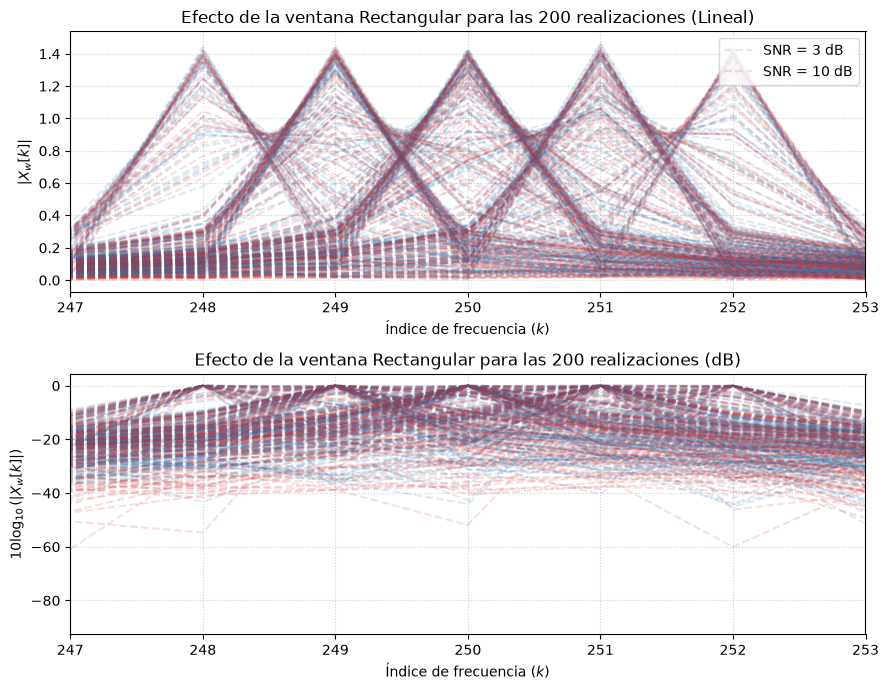

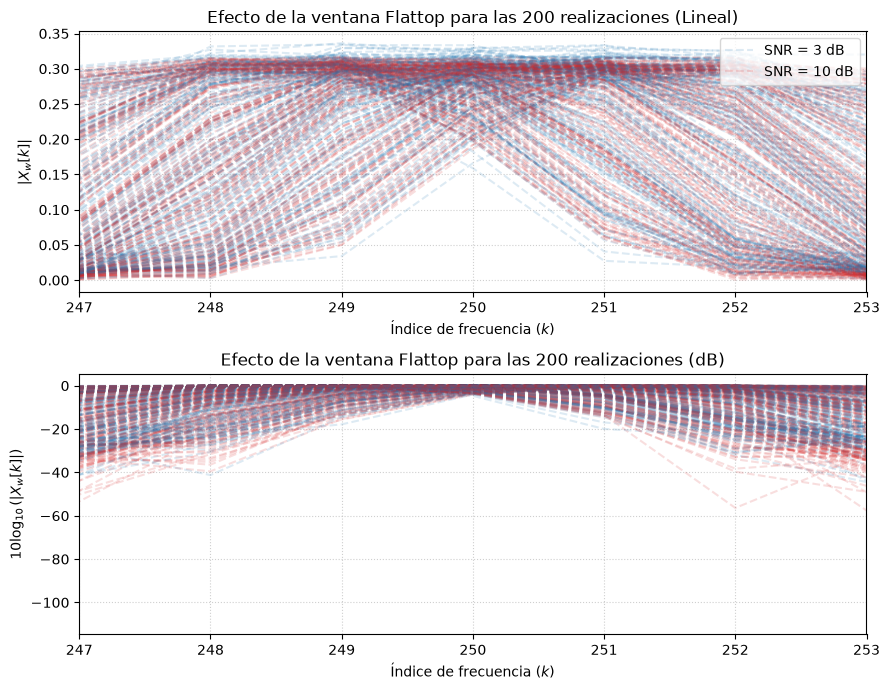

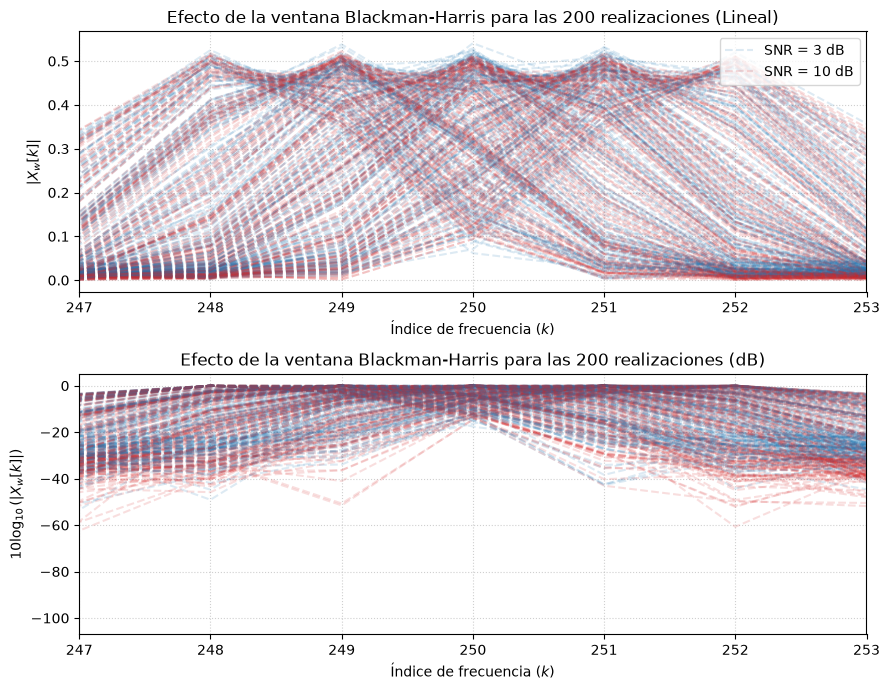

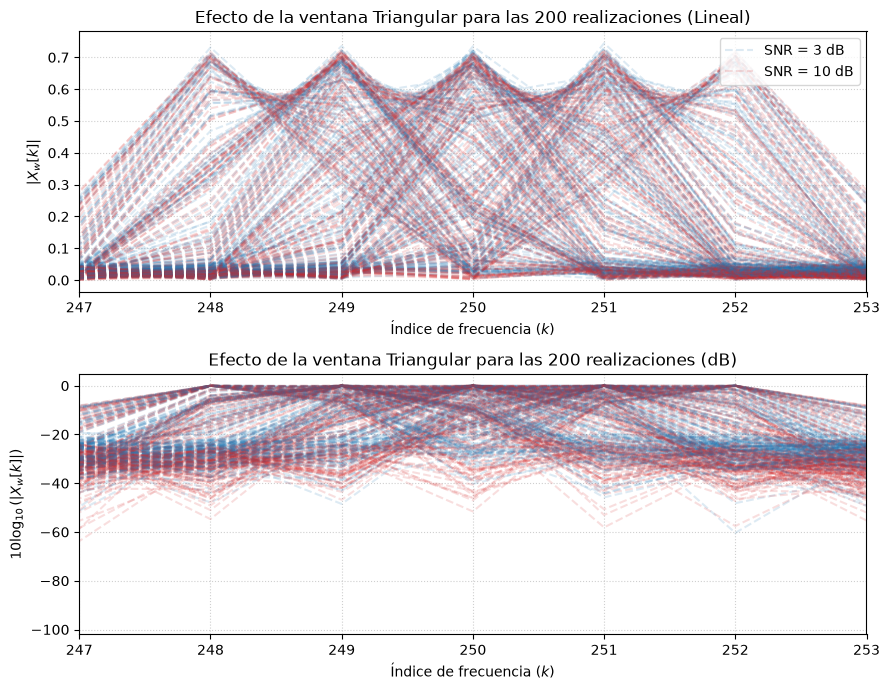

In [6]:
ventanas = {
    "Rectangular": {
        "SNR3_mod": X_SNR3_W0_mod, "SNR10_mod": X_SNR10_W0_mod,
        "SNR3_dB":  X_SNR3_W0_dB,  "SNR10_dB":  X_SNR10_W0_dB,
        "color3": "tab:blue", "color10": "tab:red"
    },
    "Flattop": {
        "SNR3_mod": X_SNR3_W1_mod, "SNR10_mod": X_SNR10_W1_mod,
        "SNR3_dB":  X_SNR3_W1_dB,  "SNR10_dB":  X_SNR10_W1_dB,
        "color3": "tab:blue", "color10": "tab:red"
    },
    "Blackman-Harris": {
        "SNR3_mod": X_SNR3_W2_mod, "SNR10_mod": X_SNR10_W2_mod,
        "SNR3_dB":  X_SNR3_W2_dB,  "SNR10_dB":  X_SNR10_W2_dB,
        "color3": "tab:blue", "color10": "tab:red"
    },
    "Triangular": {
        "SNR3_mod": X_SNR3_W3_mod, "SNR10_mod": X_SNR10_W3_mod,
        "SNR3_dB":  X_SNR3_W3_dB,  "SNR10_dB":  X_SNR10_W3_dB,
        "color3": "tab:blue", "color10": "tab:red"
    },
}
M = 200 #cantidad de realizaciones a graficar M<=R, sino error!!

for idx, (nombre, datos) in enumerate(ventanas.items(), start=1):

    plt.figure(idx, figsize=(9, 7))

    # ---------- Subplot lineal ----------
    plt.subplot(2, 1, 1)
    for r in np.arange(0, M):
        lbl3 = "SNR = 3 dB" if r == 0 else ""
        lbl10 = "SNR = 10 dB" if r == 0 else ""

        plt.plot(datos["SNR3_mod"][:, r], color=datos["color3"],
                  linestyle='--', alpha=0.15, label=lbl3)
        plt.plot(datos["SNR10_mod"][:, r], color=datos["color10"],
                  linestyle='--', alpha=0.15, label=lbl10)

    plt.xlabel("Índice de frecuencia ($k$)")
    plt.xlim(247, 253)
    plt.ylabel("$|X_w[k]|$")
    plt.title(f"Efecto de la ventana {nombre} para las 200 realizaciones (Lineal)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')

    # ---------- Subplot en dB ----------
    plt.subplot(2, 1, 2)
    for r in np.arange(0, M):
        lbl3 = "SNR = 3 dB" if r == 0 else ""
        lbl10 = "SNR = 10 dB" if r == 0 else ""

        plt.plot(datos["SNR3_dB"][:, r], color=datos["color3"],
                  linestyle='--', alpha=0.15, label=lbl3)
        plt.plot(datos["SNR10_dB"][:, r], color=datos["color10"],
                  linestyle='--', alpha=0.15, label=lbl10)

    plt.xlabel("Índice de frecuencia ($k$)")
    plt.ylabel(r"$10 \log_{10}(|X_w[k]|)$")
    plt.xlim(247, 253)
    plt.title(f"Efecto de la ventana {nombre} para las 200 realizaciones (dB)")
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

_Figura 1. efecto de las distintas ventanas en el espectro de las frecuencias_

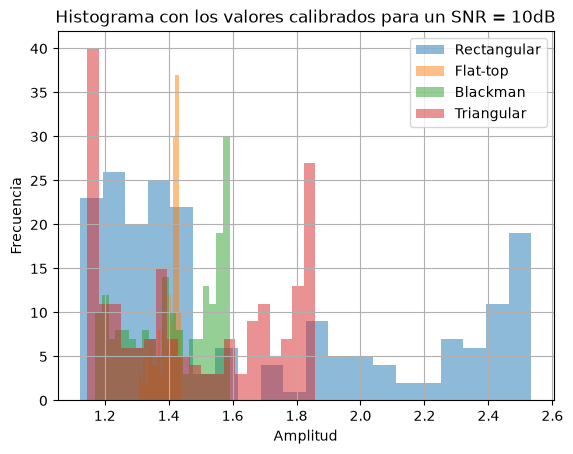

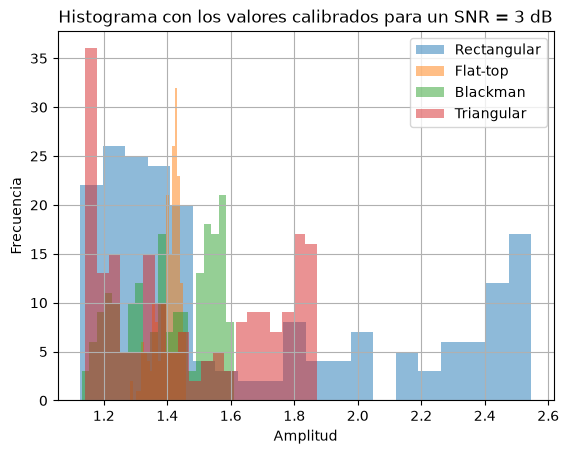

In [7]:
#%%Histogramas 
#SNR 10
plt.figure()
plt.title("Histograma con los valores calibrados para un SNR = 10dB")
plt.hist(array_SNR10_w0, bins=20, alpha=0.5, label='Rectangular')
plt.hist(array_SNR10_w1, bins=20, alpha=0.5, label='Flat-top')
plt.hist(array_SNR10_w2, bins=20, alpha=0.5, label='Blackman')
plt.hist(array_SNR10_w3, bins=20, alpha=0.5, label='Triangular')

plt.xlabel('Amplitud')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid()
plt.show()


#SNR 3
plt.figure()
plt.title("Histograma con los valores calibrados para un SNR = 3 dB")
plt.hist(array_SNR3_w0, bins=20, alpha=0.5, label='Rectangular')
plt.hist(array_SNR3_w1, bins=20, alpha=0.5, label='Flat-top')
plt.hist(array_SNR3_w2, bins=20, alpha=0.5, label='Blackman')
plt.hist(array_SNR3_w3, bins=20, alpha=0.5, label='Triangular')

plt.xlabel('Amplitud')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid()
plt.show()


_Figura 2. histogramas de amplitud con las 4 ventanas_

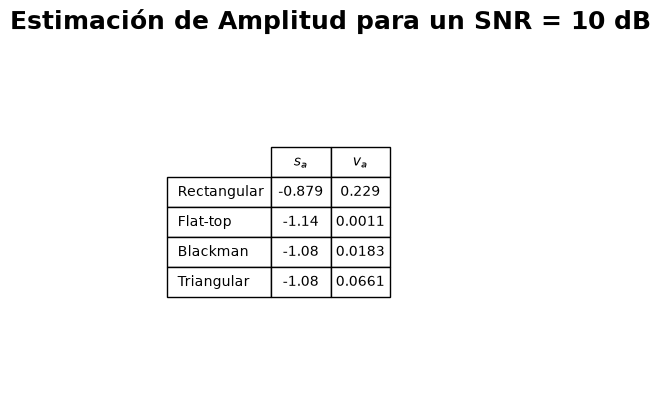

In [8]:
#%%Tablas
#SNR10
#amplitud
filas = ['Rectangular', 'Flat-top', 'Blackman', 'Triangular']
columnas = [r'$s_a$', r'$v_a$']

fig, ax = plt.subplots()

ax.axis('off')

datos = [
    [f'{sa[0]:.3g}', f'{va[0]:.3g}'],
    [f'{sa[1]:.3g}', f'{va[1]:.3g}'],
    [ f'{sa[2]:.3g}', f'{va[2]:.3g}'],
    [f'{sa[3]:.3g}', f'{va[3]:.3g}']
]

tabla = ax.table(
    cellText=datos,
    rowLabels=filas,
    colLabels=columnas,
    cellLoc='center',
    loc='center',
    colWidths=[0.12, 0.12, 0.12]
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 1.8)

plt.title('Estimación de Amplitud para un SNR = 10 dB', fontsize=18, fontweight='bold')
plt.show()

_Tabla 1. Estimador de amplitud para un SNR de 10 dB_

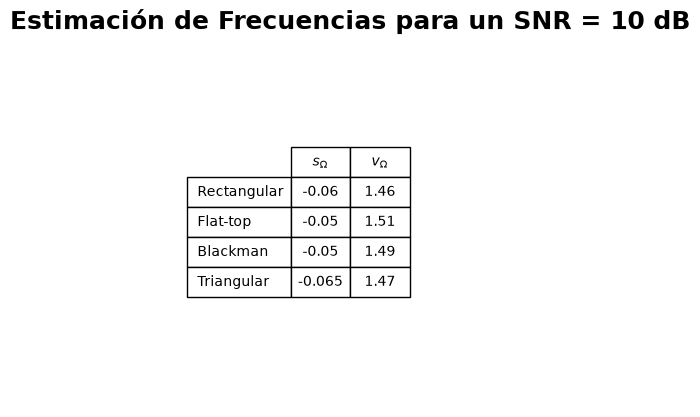

In [9]:
#frecuencias
filas = ['Rectangular', 'Flat-top', 'Blackman', 'Triangular']
columnas = [r'$s_{\Omega}$', r'$v_{\Omega}$']

fig, ax = plt.subplots()

ax.axis('off')

datos = [
    [f'{sO[0]:.3g}', f'{vO[0]:.3g}'],
    [f'{sO[1]:.3g}', f'{vO[1]:.3g}'],
    [ f'{sO[2]:.3g}', f'{vO[2]:.3g}'],
    [f'{sO[3]:.3g}', f'{vO[3]:.3g}']
]

tabla = ax.table(
    cellText=datos,
    rowLabels=filas,
    colLabels=columnas,
    cellLoc='center',
    loc='center',
    colWidths=[0.12, 0.12, 0.12]
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 1.8)

plt.title('Estimación de Frecuencias para un SNR = 10 dB', fontsize=18, fontweight='bold')
plt.show()

_Tabla 3. Estimador de frecuencias para un SNR de 10 dB_

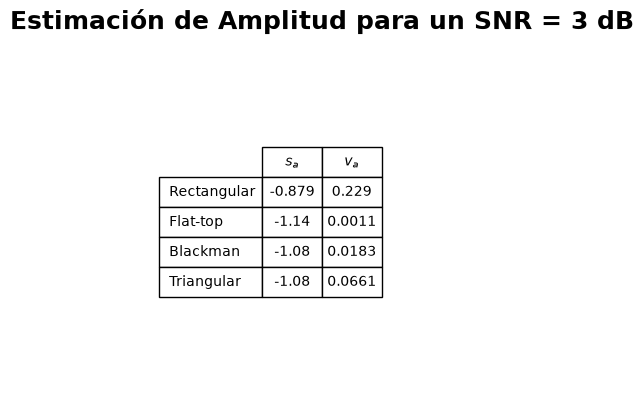

In [10]:
#SNR 3
#amplitud
filas = ['Rectangular', 'Flat-top', 'Blackman', 'Triangular']
columnas = [r'$s_a$', r'$v_a$']

fig, ax = plt.subplots()

ax.axis('off')

datos = [
    [f'{sa[0]:.3g}', f'{va[0]:.3g}'],
    [f'{sa[1]:.3g}', f'{va[1]:.3g}'],
    [ f'{sa[2]:.3g}', f'{va[2]:.3g}'],
    [f'{sa[3]:.3g}', f'{va[3]:.3g}']
]

tabla = ax.table(
    cellText=datos,
    rowLabels=filas,
    colLabels=columnas,
    cellLoc='center',
    loc='center',
    colWidths=[0.12, 0.12, 0.12]
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 1.8)

plt.title('Estimación de Amplitud para un SNR = 3 dB', fontsize=18, fontweight='bold')
plt.show()

_Tabla 3. Estimador de amplitud para un SNR de 3 dB_

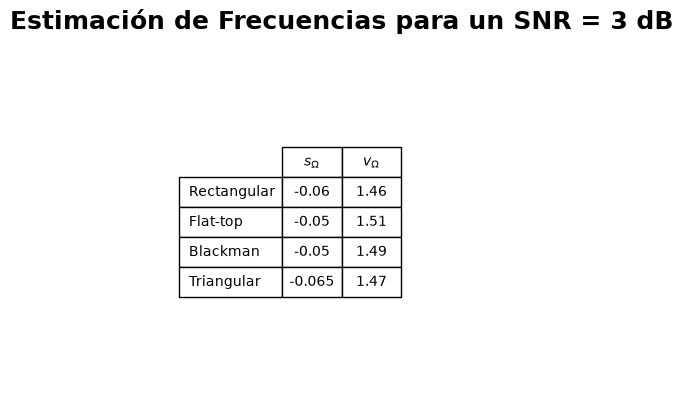

In [11]:
#frecuencias
filas = ['Rectangular', 'Flat-top', 'Blackman', 'Triangular']
columnas = [r'$s_{\Omega}$', r'$v_{\Omega}$']

fig, ax = plt.subplots()

ax.axis('off')

datos = [
    [f'{sO[0]:.3g}', f'{vO[0]:.3g}'],
    [f'{sO[1]:.3g}', f'{vO[1]:.3g}'],
    [ f'{sO[2]:.3g}', f'{vO[2]:.3g}'],
    [f'{sO[3]:.3g}', f'{vO[3]:.3g}']
]

tabla = ax.table(
    cellText=datos,
    rowLabels=filas,
    colLabels=columnas,
    cellLoc='center',
    loc='center',
    colWidths=[0.12, 0.12, 0.12]
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 1.8)

plt.title('Estimación de Frecuencias para un SNR = 3 dB', fontsize=18, fontweight='bold')
plt.show()

_Tabla 4. Estimador de frecuencias para un SNR de 3 dB_

#### Análisis:

*Estimador de Amplitud*


Los ventaneos con menor varianza de amplitud son aquellos que son más exactos, ya que el sesgo puede ser corregido calibrando el resultado del estimador como se realizó para la _Figura 2_. De esta forma el resultado del estimador tendrá un error menor, ya que este depende del desvío que pueda tener el valor obtenido del real.

Se destaca de las tablas 1 y 3 que la potencia del ruido no afecta los valores de sesgo y varianza de la amplitud. Por otro lado estas características se ven afectadas por el tipo de ventaneo utilizado, concluyendo que la ventana más apta para esta señal es la Flat-top y la menos exacta es la Rectangular debido a los valores que le atibuyen a la varianza.

Se presenta una relación de compromiso entre el sesgo y la varianza que atribuyen los ventaneos, ya que al disminuir la segunda propiedad, la primera aumenta, haciendo que el espectro de la señal pierda detalles y características que podrían ser importantes en otro tipo de señal como podrían ser diferencias de amplitud entre bins o picos que desaparecen.

*Estimador de frecuencias*

Las _tablas 2 y 3_ nos demuestran que un estimador de frecuencia como el planteado no modifica distiguiblemente su utilidad dependiendo del ventaneo que se le aplique a la señal, o de la potencia del ruido mientras esta toma valores cuyos SNR estén entre 3 y 10 dB. Por lo que se concluye que todas las ventanas utilizadas son aptas para estimar la frecuencia de la señal sinusoidal.